In [1]:
import os 
import numpy as np 
import pandas as pd 
 
file_counts = {}
 
for dirname, _, filenames in os.walk('/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/'): 
    file_counts[dirname] = len(filenames)

for dirname, count in file_counts.items():
    print(f"Subdirectory: {dirname}, Number of files: {count}")

Subdirectory: /kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/, Number of files: 1
Subdirectory: /kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/Normal cases, Number of files: 1208
Subdirectory: /kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/Malignant cases, Number of files: 1201
Subdirectory: /kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset/Benign cases, Number of files: 1200


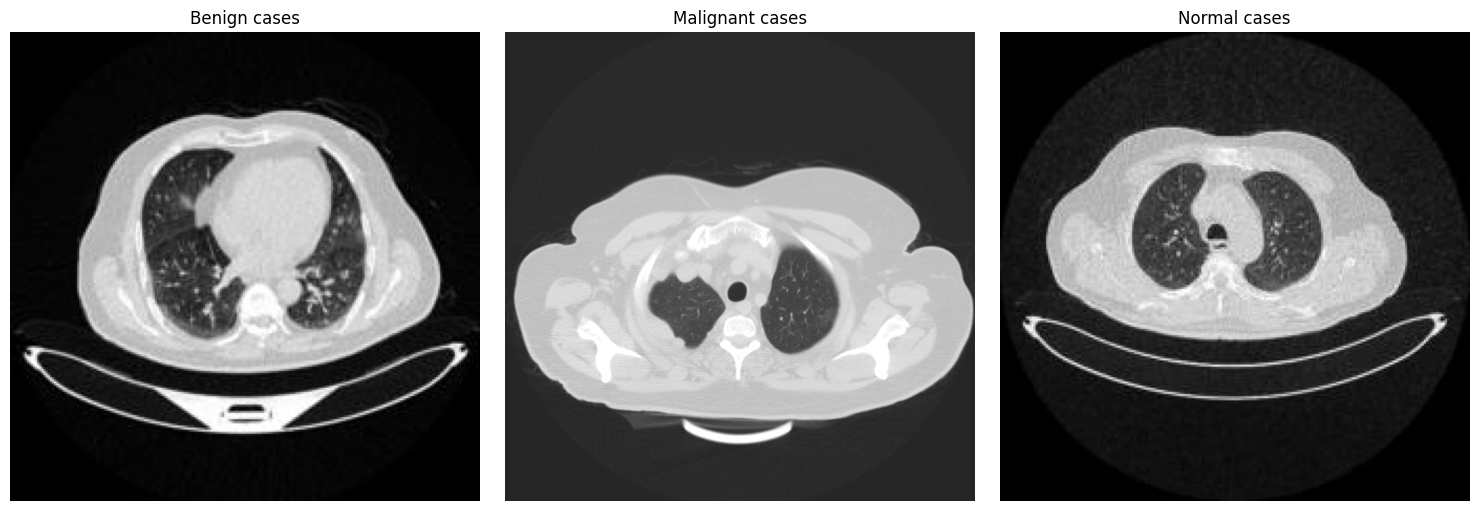

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_path = '/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset'

benign_path = os.path.join(base_path, 'Benign cases')
malignant_path = os.path.join(base_path, 'Malignant cases')
normal_path = os.path.join(base_path, 'Normal cases')

# Function to get first image from a folder
def get_first_image(folder_path):
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):  # Check for common image extensions
            return os.path.join(folder_path, filename)
    return None

# Get one image from each folder
benign_img = get_first_image(benign_path)
malignant_img = get_first_image(malignant_path)
normal_img = get_first_image(normal_path)

# Create figure with 3 subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Load and display Benign image
if benign_img:
    img1 = mpimg.imread(benign_img)
    ax1.imshow(img1, cmap='gray')  # Using gray colormap since these are likely CT scans
    ax1.set_title('Benign cases')
    ax1.axis('off')  # Hide axes

# Load and display Malignant image
if malignant_img:
    img2 = mpimg.imread(malignant_img)
    ax2.imshow(img2, cmap='gray')
    ax2.set_title('Malignant cases')
    ax2.axis('off')

# Load and display Normal image
if normal_img:
    img3 = mpimg.imread(normal_img)
    ax3.imshow(img3, cmap='gray')
    ax3.set_title('Normal cases')
    ax3.axis('off')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [3]:
import os
import shutil
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd  # Added for table display

random.seed(42) 

original_base = '/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset'
benign_dir = os.path.join(original_base, 'Benign cases')
malignant_dir = os.path.join(original_base, 'Malignant cases')
normal_dir = os.path.join(original_base, 'Normal cases')
 
BASE_DIR = '/kaggle/working/lung_cancer_split'
train_dir = os.path.join(BASE_DIR, 'train')
validation_dir = os.path.join(BASE_DIR, 'validation')

for dir_path in [os.path.join(train_dir, cls) for cls in ['benign', 'malignant', 'normal']] + \
                [os.path.join(validation_dir, cls) for cls in ['benign', 'malignant', 'normal']]:
    os.makedirs(dir_path, exist_ok=True)

def count_images(directory):
    return len([f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

# Collect counts
counts = {
    "Class": ["Benign", "Malignant", "Normal"],
    "Count": [
        count_images(benign_dir),
        count_images(malignant_dir),
        count_images(normal_dir)
    ]
}


display(pd.DataFrame(counts))

,Class,Count
0,Benign,1200
1,Malignant,1201
2,Normal,1208


In [5]:
def split_and_copy(src_dir, train_dest, val_dest, train_ratio=0.8):
    files = [f for f in os.listdir(src_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(files)
    split_idx = int(len(files) * train_ratio)
    train_files, val_files = files[:split_idx], files[split_idx:]
    
    for f in train_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(train_dest, f))
    for f in val_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(val_dest, f))
    
    return len(train_files), len(val_files)

# Perform the split
benign_train_count, benign_val_count = split_and_copy(benign_dir, 
                                                     os.path.join(train_dir, 'benign'),
                                                     os.path.join(validation_dir, 'benign'))
malignant_train_count, malignant_val_count = split_and_copy(malignant_dir,
                                                           os.path.join(train_dir, 'malignant'),
                                                           os.path.join(validation_dir, 'malignant'))
normal_train_count, normal_val_count = split_and_copy(normal_dir,
                                                     os.path.join(train_dir, 'normal'),
                                                     os.path.join(validation_dir, 'normal'))
 
split_counts = {
    "Class": ["Benign", "Malignant", "Normal"],
    "Train Count": [benign_train_count, malignant_train_count, normal_train_count],
    "Validation Count": [benign_val_count, malignant_val_count, normal_val_count]
}
  
print("\nAfter splitting:")
display(pd.DataFrame(split_counts))


After splitting:


,Class,Train Count,Validation Count
0,Benign,960,240
1,Malignant,960,241
2,Normal,966,242


Found 2886 images belonging to 3 classes.
Found 723 images belonging to 3 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,211,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,454,147 (13.18 MB)

 Trainable params: 3,454,147 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 25s 208ms/step - accuracy: 0.3286 - loss: 1.1874 - val_accuracy: 0.3352 - val_loss: 1.1009
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3438 - loss: 1.0880 - val_accuracy: 0.3158 - val_loss: 1.0837
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - accuracy: 0.3529 - loss: 1.1015 - val_accuracy: 0.3509 - val_loss: 1.0947
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 274us/step - accuracy: 0.4688 - loss: 1.0735 - val_accuracy: 0.2105 - val_loss: 1.1025
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 176ms/step - accuracy: 0.3703 - loss: 1.0955 - val_accuracy: 0.4162 - val_loss: 1.0848
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step - accuracy: 0.3750 - loss: 1.1272 - val_accuracy: 0.3684 - val_loss: 1.1050
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 180ms/step - accuracy: 0.3826 - loss: 1.0916 - val_accuracy: 0.4304 - val_loss: 1.0308
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 305us/step - accuracy: 0.5938 - loss: 0.9637 - val_accuracy: 

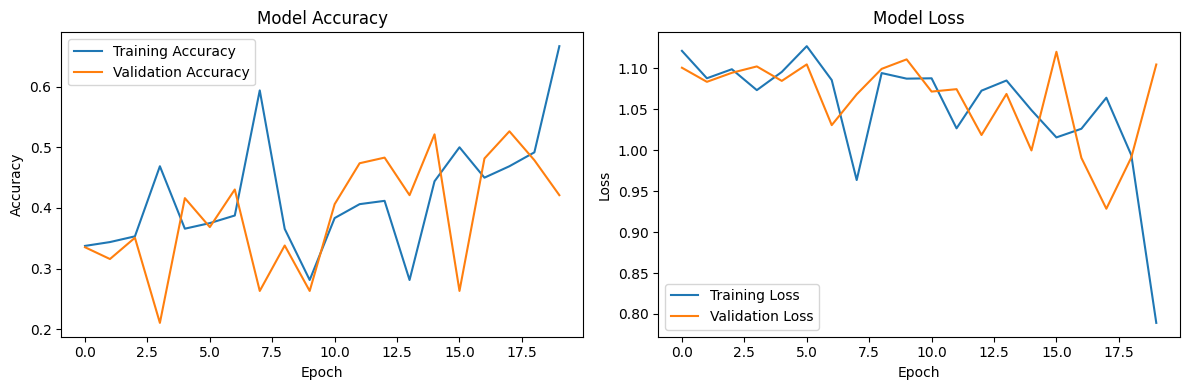

In [5]:
import warnings 
warnings.filterwarnings("ignore", category=UserWarning, message="Your `PyDataset` class should call")
warnings.filterwarnings("ignore", category=UserWarning, message="Your input ran out of data")

# Data augmentation and generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal']
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal']
)

# Build the CNN model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(150, 150, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    verbose=1
)

# Plot training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Found 2886 images belonging to 3 classes.
Found 723 images belonging to 3 classes.

Training weak learner 1/5
Found 2308 validated image filenames belonging to 3 classes.
Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 0.3899 - loss: 1.0775 - val_accuracy: 0.5048 - val_loss: 0.9137 - learning_rate: 5.0000e-04
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 274us/step - accuracy: 0.4688 - loss: 1.0350 - learning_rate: 5.0000e-04
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.5783 - loss: 0.9025 - val_accuracy: 0.6473 - val_loss: 0.7281 - learning_rate: 5.0000e-04
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 189us/step - accuracy: 0.4375 - loss: 1.1047 - learning_rate: 5.0000e-04
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.6652 - loss: 0.7543 - val_accuracy: 0.7580 - val_loss: 0.5668 - learning_rate: 5.0000e-04
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 144us/step - accuracy: 0.6875 - loss: 0.7219 - learning_rate: 5.0000e-04
Epoch 7/30
72/72

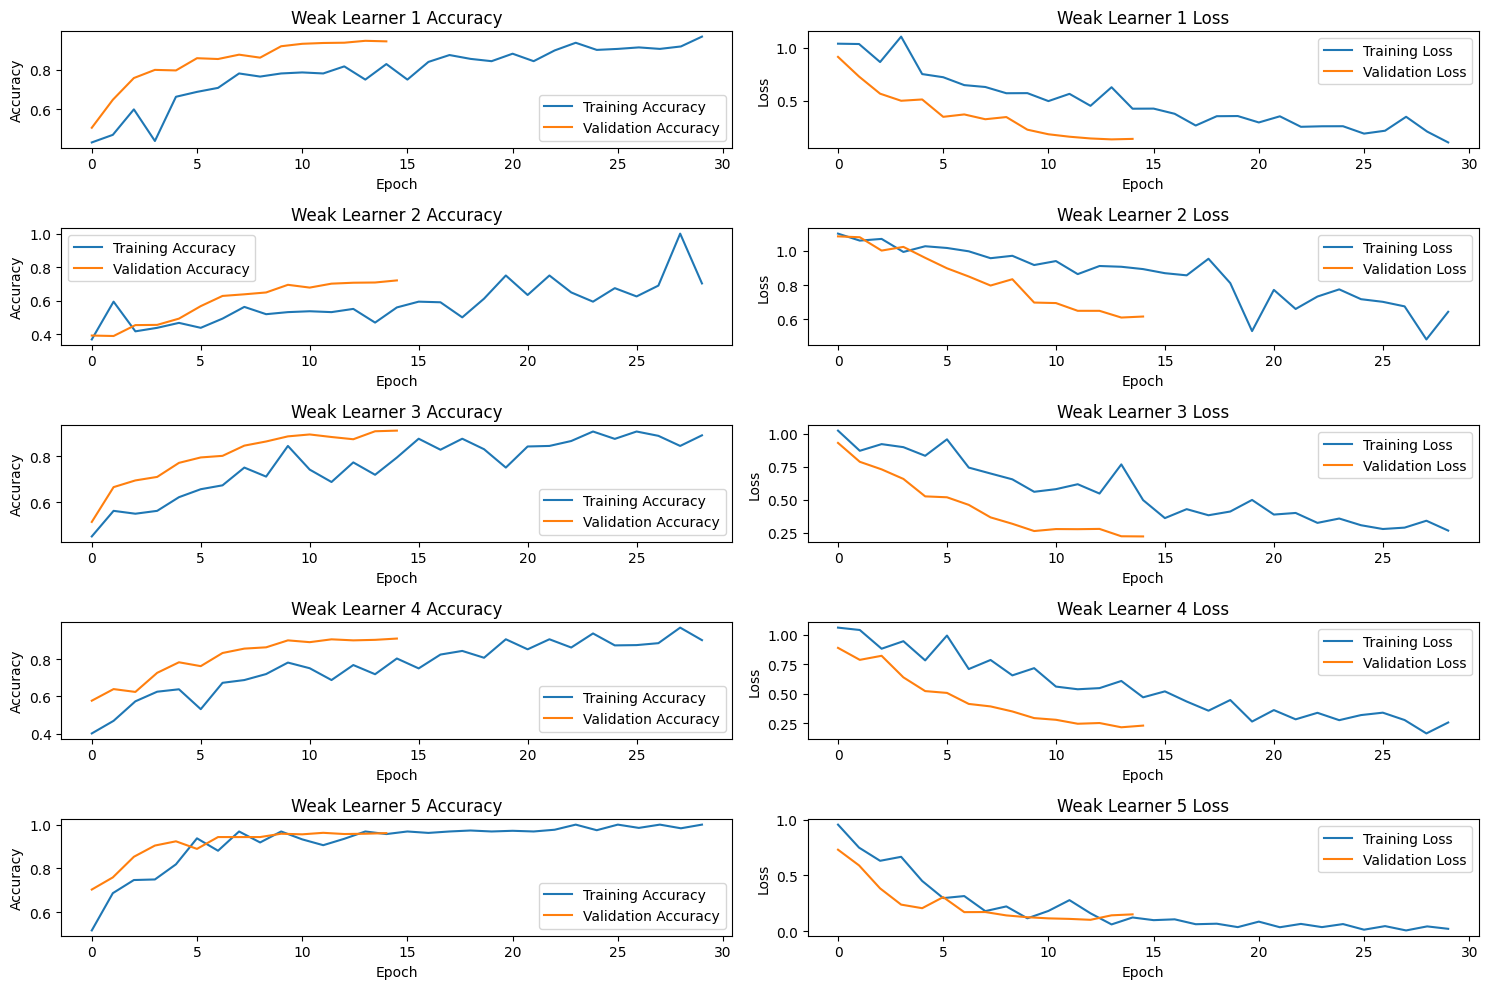


Validation Accuracy Comparison Table:
      Model Validation Accuracy
  Learner 1              0.9474
  Learner 2              0.7206
  Learner 3              0.9101
  Learner 4              0.9101
  Learner 5              0.9627
Stacking LR              0.9751
Stacking RF              1.0000
     Voting              0.8783


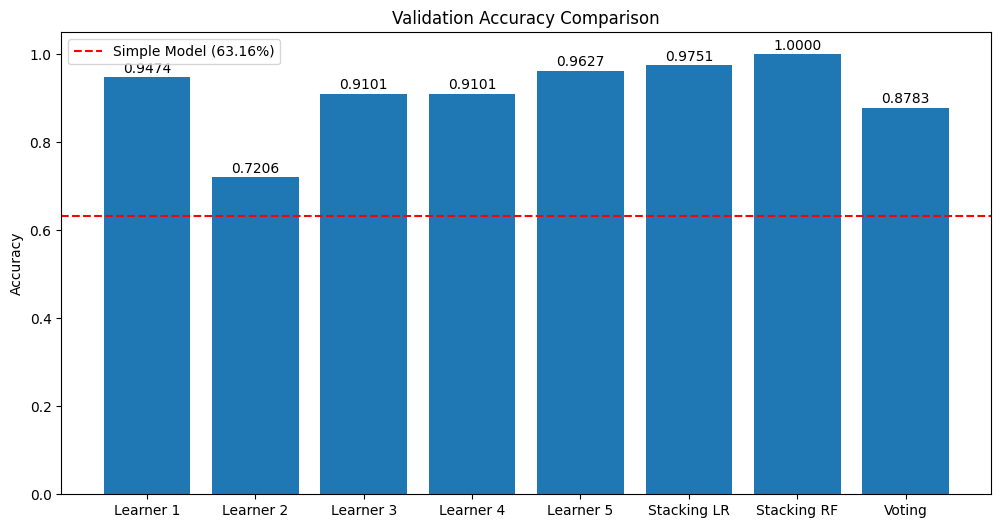

In [34]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Your `PyDataset` class should call")
warnings.filterwarnings("ignore", category=UserWarning, message="Your input ran out of data")
# Suppress specific callback warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Learning rate reduction is conditioned on metric `val_loss`")
warnings.filterwarnings("ignore", category=UserWarning, message="Early stopping conditioned on metric `val_loss`")

import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Set seeds
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Paths
train_dir = '/kaggle/working/lung_cancer_split/train'
validation_dir = '/kaggle/working/lung_cancer_split/validation'

# Data augmentation variations
augmentations = [
    ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True, fill_mode='nearest'),
    ImageDataGenerator(rescale=1./255, width_shift_range=0.2, height_shift_range=0.2, fill_mode='nearest'),
    ImageDataGenerator(rescale=1./255, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'),
    ImageDataGenerator(rescale=1./255, rotation_range=10, width_shift_range=0.1, fill_mode='nearest'),
    ImageDataGenerator(rescale=1./255, brightness_range=(0.8, 1.2), fill_mode='nearest')
]
val_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_generator_full = augmentations[0].flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal'],
    shuffle=True
)
validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal'],
    shuffle=False
)

train_steps = max(1, train_generator_full.samples // train_generator_full.batch_size)
val_steps = (validation_generator.samples + validation_generator.batch_size - 1) // validation_generator.batch_size

# Collect all training files and labels
train_files = [os.path.join(train_dir, f) for f in train_generator_full.filenames]
train_labels = train_generator_full.classes
class_indices = train_generator_full.class_indices
class_names = list(class_indices.keys())

# Define weak learner with variation
def create_weak_learner(index):
    filters = [
        (32, 64, 128, 128),
        (16, 32, 64, 96),
        (32, 48, 96, 128),
        (24, 48, 96, 128),
        (32, 64, 96, 128)
    ][index % 5]
    dropout = [0.5, 0.4, 0.3, 0.5, 0.4][index % 5]
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(150, 150, 3)),
        tf.keras.layers.Conv2D(filters[0], (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(filters[1], (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(filters[2], (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(filters[3], (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Training callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
]

# Build and train ensemble
n_learners = 5
weak_learners = []
histories = []

for i in range(n_learners):
    print(f"\nTraining weak learner {i+1}/{n_learners}")
    train_idx, _ = train_test_split(range(len(train_files)), train_size=0.8, random_state=i)
    train_files_sub = [train_files[idx] for idx in train_idx]
    train_labels_sub = [train_labels[idx] for idx in train_idx]
    train_df = pd.DataFrame({'filename': train_files_sub, 'class': [class_names[label] for label in train_labels_sub]})
    train_generator = augmentations[i].flow_from_dataframe(
        train_df,
        x_col='filename',
        y_col='class',
        target_size=(150, 150),
        batch_size=32,
        class_mode='categorical',
        shuffle=True,
        seed=i
    )
    train_steps_sub = max(1, len(train_files_sub) // train_generator.batch_size)
    model = create_weak_learner(i)
    history = model.fit(
        train_generator,
        steps_per_epoch=train_steps_sub,
        epochs=30,
        validation_data=validation_generator,
        validation_steps=val_steps,
        callbacks=callbacks,
        verbose=1,
        validation_freq=1  # Ensure validation runs every epoch
    )
    weak_learners.append(model)
    histories.append(history)

# Collect predictions for stacking on validation set
print("\nCollecting predictions for stacking on validation set...")
validation_generator.reset()
val_preds = []
for model in weak_learners:
    pred = model.predict(validation_generator, steps=val_steps, verbose=0)
    val_preds.append(pred)
val_preds = np.array(val_preds).transpose(1, 0, 2)
val_preds_flat = val_preds.reshape(val_preds.shape[0], -1)
print(f"val_preds shape: {val_preds.shape}, val_preds_flat shape: {val_preds_flat.shape}")

# Get true labels
validation_generator.reset()
val_true = []
for _ in range(val_steps):
    _, labels = next(validation_generator)
    val_true.extend(np.argmax(labels, axis=1))
val_true = np.array(val_true)
print(f"val_true length: {len(val_true)}")
assert len(val_true) == val_preds.shape[0], "Mismatch between predictions and labels!"

# Individual accuracies from predictions
print("\nIndividual Learner Accuracies (from predictions):")
for i, preds in enumerate(val_preds.transpose(1, 0, 2)):
    pred_labels = np.argmax(preds, axis=1)
    acc = np.mean(pred_labels == val_true)
    print(f"Learner {i+1}: {acc:.4f} (History max: {max(histories[i].history['val_accuracy']):.4f})")

# Train and evaluate meta-models
meta_model_lr = LogisticRegression(max_iter=1000)
meta_model_lr.fit(val_preds_flat, val_true)
ensemble_preds_lr = meta_model_lr.predict(val_preds_flat)
ensemble_accuracy_lr = np.mean(ensemble_preds_lr == val_true)
print(f"\nMeta-model (Logistic Regression) trained with {len(val_true)} samples")
print(f"Ensemble Validation Accuracy with Stacking LR: {ensemble_accuracy_lr:.4f}")

meta_model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
meta_model_rf.fit(val_preds_flat, val_true)
ensemble_preds_rf = meta_model_rf.predict(val_preds_flat)
ensemble_accuracy_rf = np.mean(ensemble_preds_rf == val_true)
print(f"Meta-model (Random Forest) trained with {len(val_true)} samples")
print(f"Ensemble Validation Accuracy with Stacking RF: {ensemble_accuracy_rf:.4f}")

val_preds_argmax = np.argmax(val_preds, axis=2)
ensemble_preds_vote = np.apply_along_axis(lambda x: np.bincount(x, minlength=3).argmax(), axis=1, arr=val_preds_argmax)
ensemble_accuracy_vote = np.mean(ensemble_preds_vote == val_true)
print(f"Ensemble Validation Accuracy with Majority Voting: {ensemble_accuracy_vote:.4f}")
print("Sample voting (first 5):")
print(val_preds_argmax[:5])
print("Voted:", ensemble_preds_vote[:5])
print("True:", val_true[:5])

# Plot all learners' histories
plt.figure(figsize=(15, 10))
for i in range(n_learners):
    plt.subplot(n_learners, 2, 2*i + 1)
    plt.plot(histories[i].history['accuracy'], label='Training Accuracy')
    plt.plot(histories[i].history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Weak Learner {i+1} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(n_learners, 2, 2*i + 2)
    plt.plot(histories[i].history['loss'], label='Training Loss')
    plt.plot(histories[i].history['val_loss'], label='Validation Loss')
    plt.title(f'Weak Learner {i+1} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

# Table and Bar plot comparing accuracies
accuracies = [max(h.history['val_accuracy']) for h in histories] + [ensemble_accuracy_lr, ensemble_accuracy_rf, ensemble_accuracy_vote]
labels = [f'Learner {i+1}' for i in range(n_learners)] + ['Stacking LR', 'Stacking RF', 'Voting']
accuracy_df = pd.DataFrame({
    'Model': labels,
    'Validation Accuracy': [f'{acc:.4f}' for acc in accuracies]
})
print("\nValidation Accuracy Comparison Table:")
print(accuracy_df.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.bar(labels, accuracies)
plt.title('Validation Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.axhline(y=0.6316, color='r', linestyle='--', label='Simple Model (63.16%)')
plt.legend()
plt.show()

Found 3609 images belonging to 3 classes.
Original dataset samples: 3609, test_steps: 113
val_preds shape: (3609, 5, 3), val_preds_flat shape: (3609, 15)
val_true length: 3609
Random Forest Stacking Accuracy on Original Dataset: 0.9942

Prediction Results on Original Dataset (Random Forest Stacking):
Predicted        Benign  Malignant  Normal  Total True Class Accuracy
True                                                                 
Benign             1192          0       8        1200       0.993333
Malignant             0       1201       0        1201            1.0
Normal               11          2    1195        1208       0.989238
Total Predicted    1203       1203    1203        3609              -

Overall Accuracy: 0.9942


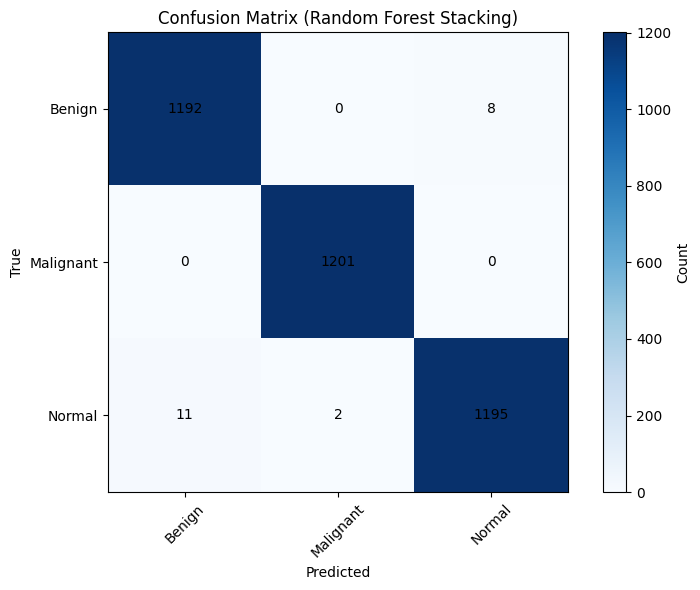

Number of misclassifications: 21


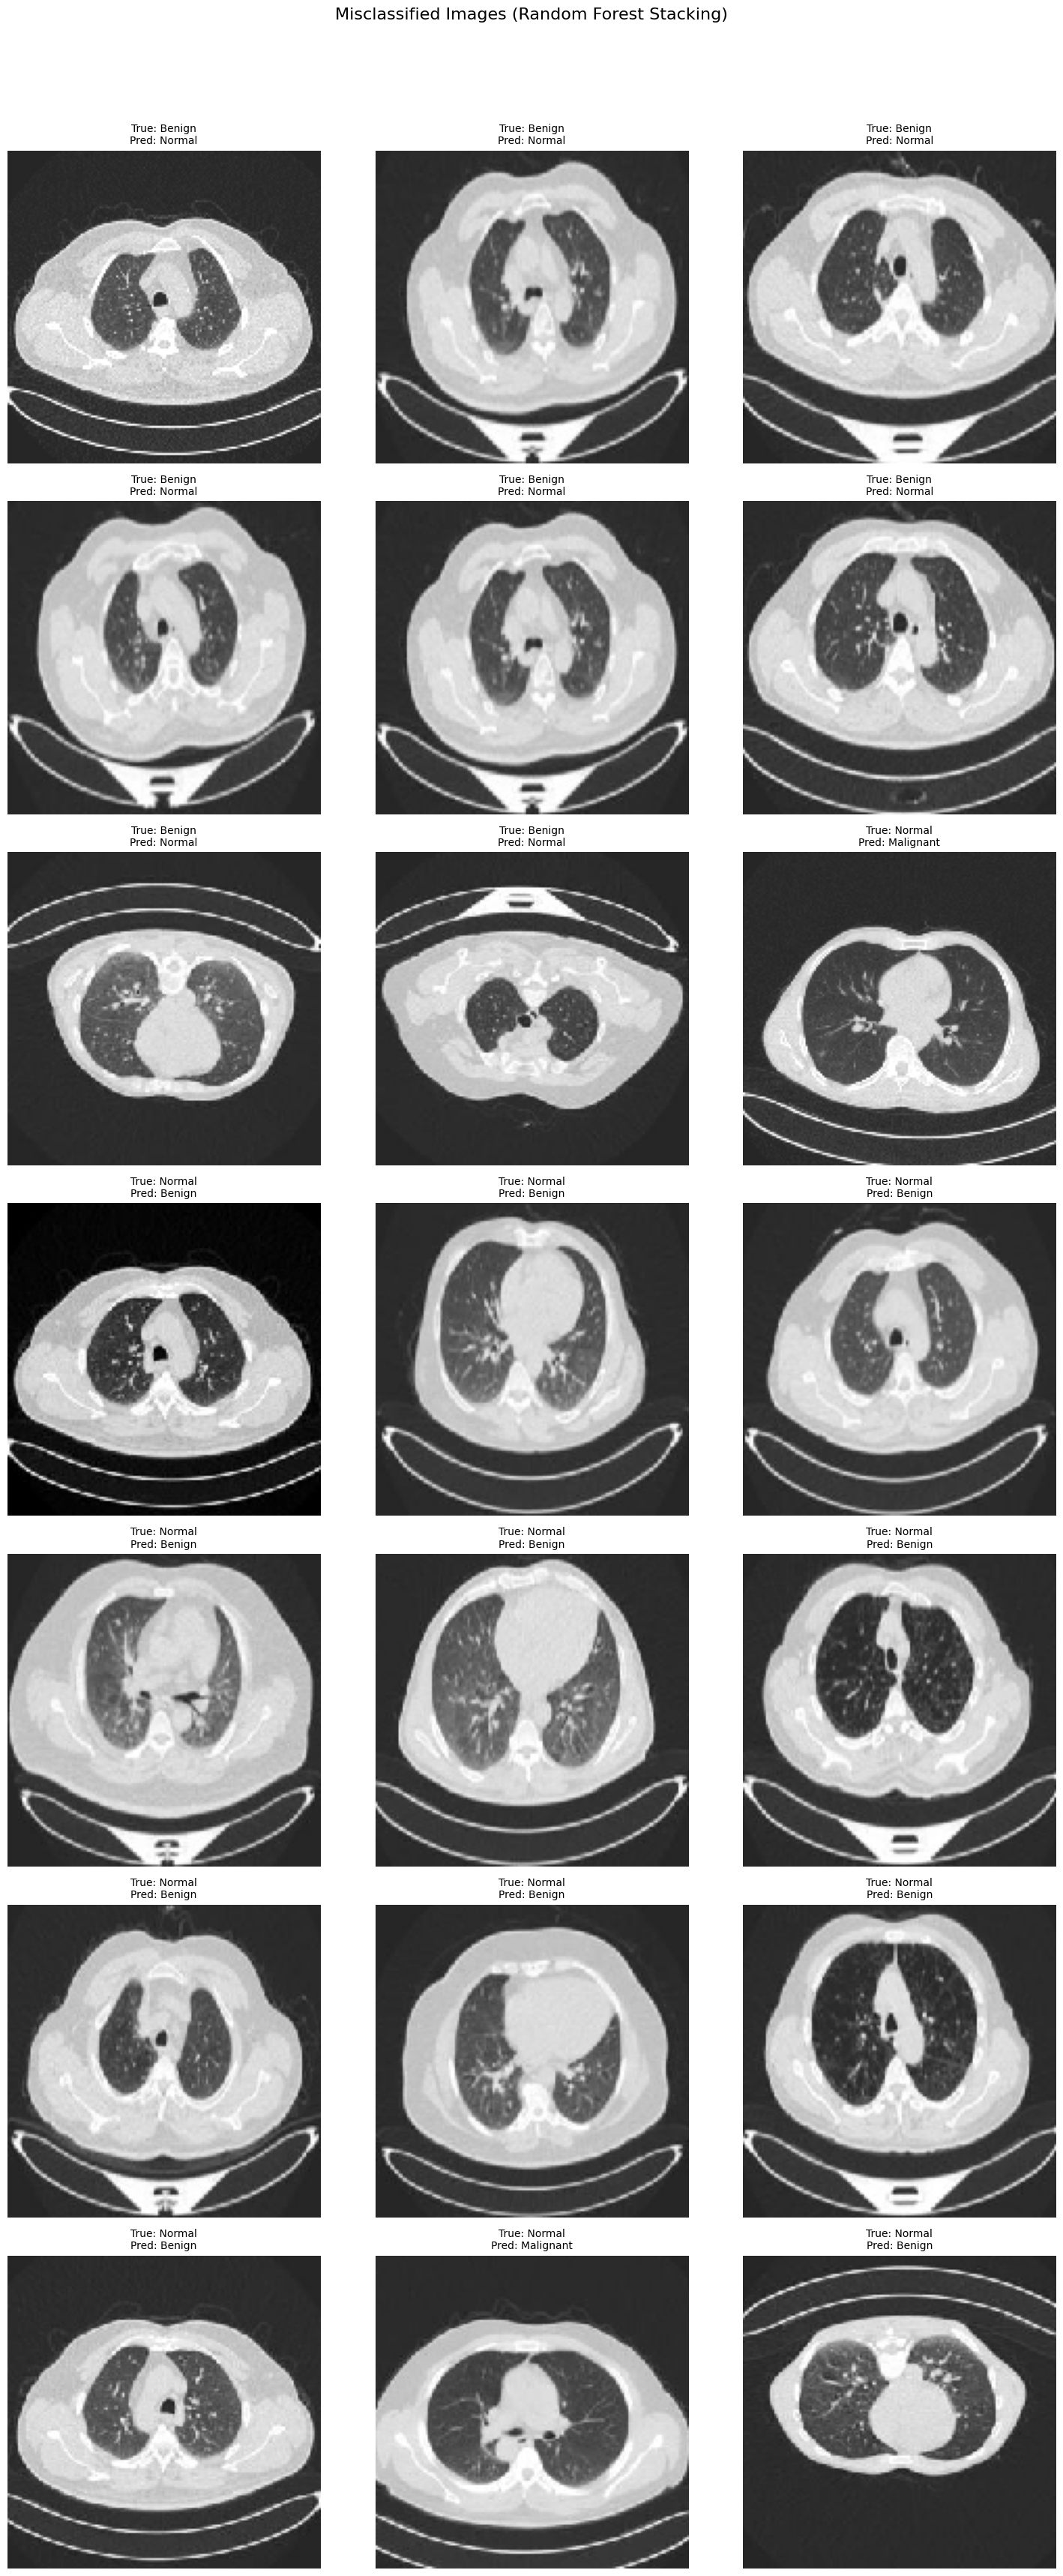

In [39]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

# Original dataset paths
original_base = '/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset'
benign_dir = os.path.join(original_base, 'Benign cases')
malignant_dir = os.path.join(original_base, 'Malignant cases')
normal_dir = os.path.join(original_base, 'Normal cases')

# Data generator for original dataset (no augmentation, just rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    original_base,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['Benign cases', 'Malignant cases', 'Normal cases'],
    shuffle=False  # Keep order for label alignment
)

# Adjust steps to cover all samples
test_steps = (test_generator.samples + test_generator.batch_size - 1) // test_generator.batch_size
print(f"Original dataset samples: {test_generator.samples}, test_steps: {test_steps}")

# Collect predictions from the 5 weak learners
print("Collecting predictions from weak learners on original dataset...")
test_generator.reset()
val_preds = []
for model in weak_learners:
    pred = model.predict(test_generator, steps=test_steps, verbose=0)
    val_preds.append(pred)
val_preds = np.array(val_preds).transpose(1, 0, 2)  # Shape: (samples, 5, 3)
val_preds_flat = val_preds.reshape(val_preds.shape[0], -1)  # Shape: (samples, 15)
print(f"val_preds shape: {val_preds.shape}, val_preds_flat shape: {val_preds_flat.shape}")

# Get true labels
test_generator.reset()
val_true = []
for _ in range(test_steps):
    _, labels = next(test_generator)
    val_true.extend(np.argmax(labels, axis=1))
val_true = np.array(val_true)
print(f"val_true length: {len(val_true)}")
assert len(val_true) == val_preds.shape[0], "Mismatch between predictions and labels!"

# Map numeric labels to class names (adjust based on generator order)
class_names = ['Benign', 'Malignant', 'Normal']  # Matches ['Benign cases', 'Malignant cases', 'Normal cases']

# Predict using the Random Forest meta-model
ensemble_preds_rf = meta_model_rf.predict(val_preds_flat)

# Calculate accuracy
ensemble_accuracy_rf = np.mean(ensemble_preds_rf == val_true)
print(f"Random Forest Stacking Accuracy on Original Dataset: {ensemble_accuracy_rf:.4f}")

# Build results table
results = []
for i in range(len(val_true)):
    true_label = class_names[val_true[i]]
    pred_label = class_names[ensemble_preds_rf[i]]
    results.append({'True Label': true_label, 'Predicted Label': pred_label})

results_df = pd.DataFrame(results)

# Summary table: Counts of true vs predicted
summary_df = pd.crosstab(results_df['True Label'], results_df['Predicted Label'], rownames=['True'], colnames=['Predicted'])
summary_df['Total True'] = summary_df.sum(axis=1)
summary_df.loc['Total Predicted'] = summary_df.sum(axis=0)

# Add accuracy per class
class_accuracy = {}
for cls in class_names:
    true_count = summary_df.loc[cls, cls] if cls in summary_df.index else 0
    total_true = summary_df.loc[cls, 'Total True'] if cls in summary_df.index else 0
    class_accuracy[cls] = true_count / total_true if total_true > 0 else 0
summary_df['Class Accuracy'] = [class_accuracy.get(cls, '-') for cls in summary_df.index]

# Display table
print("\nPrediction Results on Original Dataset (Random Forest Stacking):")
print(summary_df.to_string())
print(f"\nOverall Accuracy: {ensemble_accuracy_rf:.4f}")

# Optional: Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(summary_df.iloc[:-1, :-2].values, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix (Random Forest Stacking)')
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, summary_df.iloc[i, j], ha='center', va='center', color='black')
plt.colorbar(label='Count')
plt.tight_layout()
plt.show()

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Original dataset paths
original_base = '/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset'
class_dirs = {
    'Benign': os.path.join(original_base, 'Benign cases'),
    'Malignant': os.path.join(original_base, 'Malignant cases'),
    'Normal': os.path.join(original_base, 'Normal cases')
}
class_names = ['Benign', 'Malignant', 'Normal']

# Get file paths and true labels from the generator
test_generator.reset()
file_paths = test_generator.filepaths  # Full paths to images in order
assert len(file_paths) == len(val_true), "Mismatch between file paths and true labels!"

# Identify misclassifications
misclassified_indices = np.where(val_true != ensemble_preds_rf)[0]
misclassified_paths = [file_paths[i] for i in misclassified_indices]
misclassified_true = [val_true[i] for i in misclassified_indices]
misclassified_pred = [ensemble_preds_rf[i] for i in misclassified_indices]

print(f"Number of misclassifications: {len(misclassified_indices)}")

# Plot misclassified images
n_misclassified = len(misclassified_indices)
cols = 3  # 3 images per row
rows = int(np.ceil(n_misclassified / cols))  # Ceiling division for enough rows (21 / 3 = 7)

plt.figure(figsize=(15, 5 * rows))  # Width=15, Height=5 per row
for i, (img_path, true_label, pred_label) in enumerate(zip(misclassified_paths, misclassified_true, misclassified_pred)):
    # Load and preprocess the image
    img = load_img(img_path, target_size=(150, 150))
    img_array = img_to_array(img) / 255.0  # Rescale as per model input

    # Plot the image with true and predicted labels in the title
    plt.subplot(rows, cols, i + 1)  # i + 1 because subplot indices start at 1
    plt.imshow(img_array)
    plt.axis('off')
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=10)

plt.suptitle('Misclassified Images (Random Forest Stacking)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for suptitle
plt.show()

# Summary of misclassifications
misclassification_summary = pd.DataFrame({
    'Image Path': misclassified_paths,
    'True Label': [class_names[t] for t in misclassified_true],
    'Predicted Label': [class_names[p] for p in misclassified_pred]
})
#print("\nMisclassification Details:")
#print(misclassification_summary.to_string(index=False))

In [40]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Your `PyDataset` class should call")
warnings.filterwarnings("ignore", category=UserWarning, message="Your input ran out of data")
warnings.filterwarnings("ignore", category=UserWarning, message="Learning rate reduction is conditioned on metric `val_loss`")
warnings.filterwarnings("ignore", category=UserWarning, message="Early stopping conditioned on metric `val_loss`")

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras_tuner import RandomSearch
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Paths
train_dir = '/kaggle/working/lung_cancer_split/train'
validation_dir = '/kaggle/working/lung_cancer_split/validation'

# Data augmentation for training, plain rescaling for validation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal'],
    shuffle=True
)
validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    classes=['benign', 'malignant', 'normal'],
    shuffle=False
)

train_steps = (train_generator.samples + train_generator.batch_size - 1) // train_generator.batch_size  # 2886 / 32 = 90+
val_steps = (validation_generator.samples + validation_generator.batch_size - 1) // validation_generator.batch_size  # 723 / 32 = 22+

# Function to build and tune a model
def build_model(model_name, hp):
    if model_name == 'InceptionV3':
        base_model = tf.keras.applications.InceptionV3(
            input_shape=(150, 150, 3), include_top=False, weights='imagenet')
        preprocess_input = tf.keras.applications.inception_v3.preprocess_input
        fine_tune_options = ['mixed5', 'mixed6', 'mixed7']
    elif model_name == 'EfficientNetB3':
        base_model = tf.keras.applications.EfficientNetB3(
            input_shape=(150, 150, 3), include_top=False, weights='imagenet')
        preprocess_input = tf.keras.applications.efficientnet.preprocess_input
        fine_tune_options = ['block5a_expand_conv', 'block6a_expand_conv']
    elif model_name == 'ResNet50':
        base_model = tf.keras.applications.ResNet50(
            input_shape=(150, 150, 3), include_top=False, weights='imagenet')
        preprocess_input = tf.keras.applications.resnet.preprocess_input
        fine_tune_options = ['conv4_block1_1_conv', 'conv5_block1_1_conv']

    # Freeze base model initially
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(150, 150, 3))
    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(
        units=hp.Int(f'{model_name}_dense_units', min_value=512, max_value=2048, step=512),
        activation='relu'
    )(x)
    x = tf.keras.layers.Dropout(
        hp.Float(f'{model_name}_dropout', min_value=0.2, max_value=0.5, step=0.1)
    )(x)
    outputs = tf.keras.layers.Dense(3, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)

    # Optimizer selection
    optimizer_choice = hp.Choice(f'{model_name}_optimizer', ['adam', 'rmsprop', 'sgd'])
    lr = hp.Choice(f'{model_name}_learning_rate', [1e-3, 5e-4, 1e-4])
    if optimizer_choice == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_choice == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base_model, fine_tune_options

# Tune and train models
models_to_tune = ['InceptionV3', 'EfficientNetB3', 'ResNet50']
best_models = {}
best_hps = {}
final_histories = {}

for model_name in models_to_tune:
    print(f"\n=== Tuning and Training {model_name} ===")

    # Hyperparameter tuning
    tuner = RandomSearch(
        lambda hp: build_model(model_name, hp)[0],
        objective='val_accuracy',
        max_trials=10,
        executions_per_trial=1,
        directory='tuner_dir',
        project_name=f'{model_name}_transfer'
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]

    tuner.search(
        train_generator,
        steps_per_epoch=train_steps,
        epochs=15,
        validation_data=validation_generator,
        validation_steps=val_steps,
        callbacks=callbacks,
        verbose=1
    )

    # Get best model and hyperparameters
    best_hps[model_name] = tuner.get_best_hyperparameters(num_trials=1)[0]
    model, base_model, fine_tune_options = build_model(model_name, best_hps[model_name])

    # Fine-tuning
    fine_tune_at = fine_tune_options[-1]  # Deepest layer for fine-tuning
    base_model.trainable = True
    for layer in base_model.layers:
        if layer.name == fine_tune_at:
            break
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Final training with fine-tuning
    print(f"Final training with fine-tuning for {model_name}...")
    final_callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]
    final_histories[model_name] = model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        epochs=20,
        validation_data=validation_generator,
        validation_steps=val_steps,
        callbacks=final_callbacks,
        verbose=1
    )
    best_models[model_name] = model

# Evaluate individual models
print("\n=== Individual Model Evaluation ===")
accuracies = {}
for model_name in models_to_tune:
    val_loss, val_acc = best_models[model_name].evaluate(validation_generator, steps=val_steps, verbose=0)
    accuracies[model_name] = val_acc
    print(f"{model_name} - Validation Accuracy: {val_acc:.4f}, Loss: {val_loss:.4f}")

# Stacking ensemble
print("\n=== Stacking Ensemble ===")
val_preds = {}
validation_generator.reset()
for model_name, model in best_models.items():
    preds = model.predict(validation_generator, steps=val_steps, verbose=0)
    val_preds[model_name] = preds

# Get true labels
validation_generator.reset()
val_true = []
for _ in range(val_steps):
    _, labels = next(validation_generator)
    val_true.extend(np.argmax(labels, axis=1))
val_true = np.array(val_true)
print(f"val_true length: {len(val_true)}, val_preds shape (per model): {val_preds[models_to_tune[0]].shape}")

# Stack predictions
val_preds_flat = np.hstack([val_preds[model_name] for model_name in models_to_tune])  # Shape: (723, 9) [3 models × 3 classes]
print(f"val_preds_flat shape: {val_preds_flat.shape}")

# Logistic Regression stacking
meta_model_lr = LogisticRegression(max_iter=1000)
meta_model_lr.fit(val_preds_flat, val_true)
ensemble_preds_lr = meta_model_lr.predict(val_preds_flat)
ensemble_accuracy_lr = np.mean(ensemble_preds_lr == val_true)
accuracies['Stacking LR'] = ensemble_accuracy_lr
print(f"Ensemble Validation Accuracy with Stacking LR: {ensemble_accuracy_lr:.4f}")

# Random Forest stacking
meta_model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
meta_model_rf.fit(val_preds_flat, val_true)
ensemble_preds_rf = meta_model_rf.predict(val_preds_flat)
ensemble_accuracy_rf = np.mean(ensemble_preds_rf == val_true)
accuracies['Stacking RF'] = ensemble_accuracy_rf
print(f"Ensemble Validation Accuracy with Stacking RF: {ensemble_accuracy_rf:.4f}")

# Table output
accuracy_df = pd.DataFrame({
    'Model': list(accuracies.keys()),
    'Validation Accuracy': [f'{acc:.4f}' for acc in accuracies.values()]
})
print("\nValidation Accuracy Comparison Table:")
print(accuracy_df.to_string(index=False))

# Plotting individual model histories
plt.figure(figsize=(15, 10))
for i, model_name in enumerate(models_to_tune, 1):
    plt.subplot(2, 3, i)
    plt.plot(final_histories[model_name].history['accuracy'], label='Training Accuracy')
    plt.plot(final_histories[model_name].history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(2, 3, i + 3)
    plt.plot(final_histories[model_name].history['loss'], label='Training Loss')
    plt.plot(final_histories[model_name].history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

# Bar plot comparing accuracies
plt.figure(figsize=(10, 5))
plt.bar(accuracies.keys(), accuracies.values())
plt.title('Validation Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.show()

Trial 2 Complete [00h 02m 54s]

Best val_accuracy So Far: None
Total elapsed time: 00h 05m 52s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
512               |1024              |InceptionV3_dense_units
0.3               |0.3               |InceptionV3_dropout
sgd               |adam              |InceptionV3_optimizer
0.0001            |0.0001            |InceptionV3_learning_rate

Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 38s 298ms/step - accuracy: 0.3282 - loss: 1.1203 - val_accuracy: 0.3292 - val_loss: 1.1145 - learning_rate: 1.0000e-04
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 18s 180ms/step - accuracy: 0.3415 - loss: 1.1042 - val_accuracy: 0.3223 - val_loss: 1.1071 - learning_rate: 1.0000e-04
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 5/15
91/91 ━━━━━━━━━

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/base_tuner.py", line 265, in _run_and_update_trial
    tuner_utils.convert_to_metrics_dict(
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/tuner_utils.py", line 132, in convert_to_metrics_dict
    [convert_to_metrics_dict(elem, objective) for elem in results]
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/tuner_utils.py", line 132, in <listcomp>
    [convert_to_metrics_dict(elem, objective) for elem in results]
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/tuner_utils.py", line 145, in convert_to_metrics_dict
    best_value, _ = _get_best_value_and_best_epoch_from_history(
  File "/usr/local/lib/python3.10/dist-packages/kera

RuntimeError: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/base_tuner.py", line 265, in _run_and_update_trial
    tuner_utils.convert_to_metrics_dict(
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/tuner_utils.py", line 132, in convert_to_metrics_dict
    [convert_to_metrics_dict(elem, objective) for elem in results]
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/tuner_utils.py", line 132, in <listcomp>
    [convert_to_metrics_dict(elem, objective) for elem in results]
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/tuner_utils.py", line 145, in convert_to_metrics_dict
    best_value, _ = _get_best_value_and_best_ep